In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

C:\Users\HP\AppData\Local\Temp\ipykernel_18100\1930487762.py:34: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(), 256, [0, 256], color='gray')
C:\Users\HP\AppData\Local\Temp\ipykernel_18100\1930487762.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(runway_equalized.flatten(), 256, [0, 256], color='b')


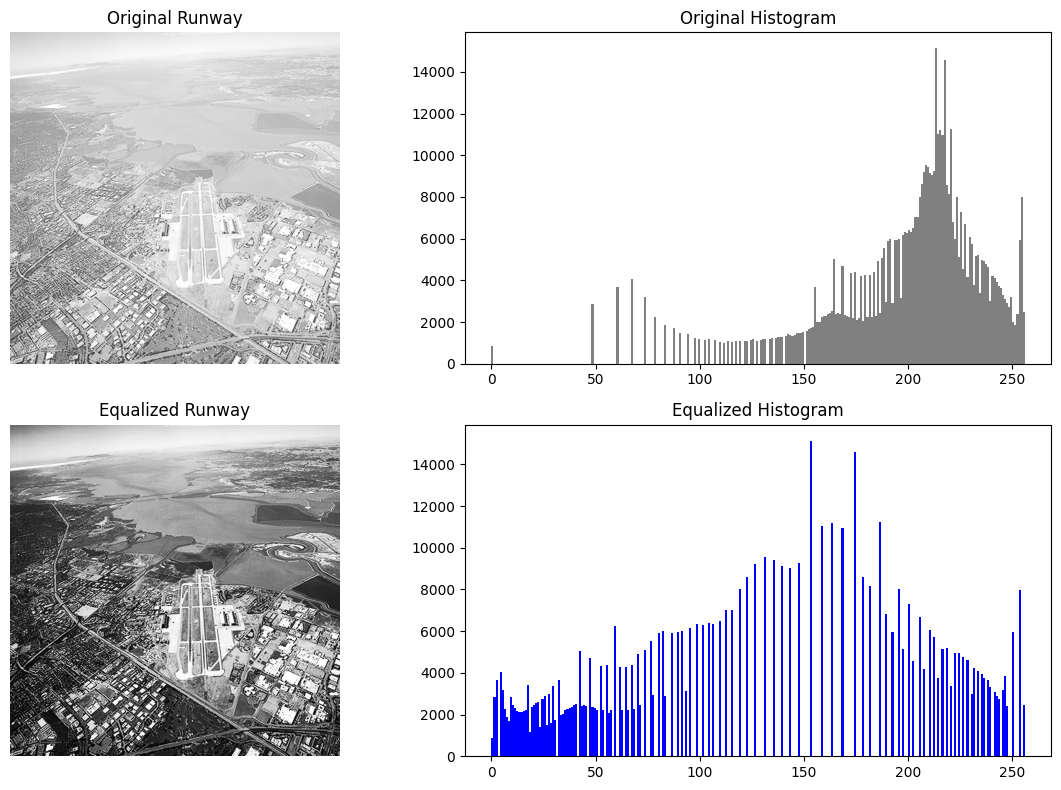

In [ ]:
def manual_histogram_equalization(image):
    # Calculate the histogram (frequency of each intensity 0-255)
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    
    cdf = hist.cumsum() # Calculate the Cumulative Distribution Function (CDF)
    
    # Normalize the CDF to the range [0, 255]
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')  # Fill masked values back with 0
    
    img_equalized = cdf[image] # Map the original pixels to the new equalized values
    
    return img_equalized

# Load the runway image
img = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)

# Apply the custom function
runway_equalized = manual_histogram_equalization(img)

cv.imwrite('results/ques3/runway_equalized_output.png', runway_equalized)

# --- Comparison Visualization ---
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Runway")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.hist(img.flatten(), 256, [0, 256], color='gray')
plt.title("Original Histogram")

plt.subplot(2, 2, 3)
plt.imshow(runway_equalized, cmap='gray')
plt.title("Equalized Runway")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.hist(runway_equalized.flatten(), 256, [0, 256], color='b')
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()